In [1]:
import pandas as pd
import numpy as np
import random

Gen skupa

In [5]:
np.random.seed(42)
n = 1000

# Generisanje karakteristika
user_ids = np.arange(1, n + 1)
ages = np.random.randint(18, 70, n)
genders = np.random.choice(['Male', 'Female', 'Other'], n, p=[0.48, 0.48, 0.04])
subscription_types = np.random.choice(['Free', 'Basic', 'Premium'], n, p=[0.3, 0.4, 0.3])
days_active = np.random.randint(0, 61, n)
avg_session_length = np.round(np.random.normal(loc=15, scale=5, size=n), 1)
total_sessions = np.random.poisson(lam=30, size=n)
total_time_spent = np.round(avg_session_length * total_sessions + np.random.normal(0, 10, size=n), 1)
num_complaints = np.random.poisson(0.3, n)
num_support_calls = np.random.poisson(0.2, n)
discount_used = np.random.choice([0, 1], n, p=[0.7, 0.3])
last_login_days_ago = np.random.randint(0, 61, n)
num_clicks = np.random.poisson(5, n)
countries = np.random.choice(['Serbia', 'Germany', 'USA', 'France', 'India'], n)

# Generisanje ciljne promenljive 'churned' na osnovu logike
churn_prob = (
    (days_active < 10).astype(int) * 0.3 +
    (subscription_types == 'Free').astype(int) * 0.25 +
    (last_login_days_ago > 30).astype(int) * 0.3 +
    (num_complaints > 2).astype(int) * 0.2 +
    (num_support_calls > 2).astype(int) * 0.15 +
    np.random.rand(n) * 0.2
)

churned = (churn_prob > 0.5).astype(int)

# Kreiranje DataFrame-a
df = pd.DataFrame({
    'user_id': user_ids,
    'age': ages,
    'gender': genders,
    'subscription_type': subscription_types,
    'days_active': days_active,
    'avg_session_length': avg_session_length,
    'total_sessions': total_sessions,
    'total_time_spent': total_time_spent,
    'num_complaints': num_complaints,
    'num_support_calls': num_support_calls,
    'discount_used': discount_used,
    'last_login_days_ago': last_login_days_ago,
    'num_clicks': num_clicks,
    'country': countries,
    'churned': churned
})

df.to_csv("users.csv", index=False)



In [6]:
df.head()

,user_id,age,gender,subscription_type,days_active,avg_session_length,total_sessions,total_time_spent,num_complaints,num_support_calls,discount_used,last_login_days_ago,num_clicks,country,churned
0,1,56,Female,Basic,32,16.9,45,739.8,1,0,1,8,6,France,0
1,2,69,Male,Free,23,12.6,30,379.8,0,0,0,42,4,Germany,1
2,3,46,Male,Premium,43,15.0,25,370.0,0,0,0,58,7,USA,0
3,4,32,Male,Premium,10,1.5,22,41.8,0,1,1,33,1,India,0
4,5,60,Male,Basic,16,17.3,35,580.1,0,0,0,26,4,India,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              1000 non-null   int64  
 1   age                  1000 non-null   int64  
 2   gender               1000 non-null   object 
 3   subscription_type    1000 non-null   object 
 4   days_active          1000 non-null   int64  
 5   avg_session_length   1000 non-null   float64
 6   total_sessions       1000 non-null   int64  
 7   total_time_spent     1000 non-null   float64
 8   num_complaints       1000 non-null   int64  
 9   num_support_calls    1000 non-null   int64  
 10  discount_used        1000 non-null   int64  
 11  last_login_days_ago  1000 non-null   int64  
 12  num_clicks           1000 non-null   int64  
 13  country              1000 non-null   object 
 14  churned              1000 non-null   int64  
dtypes: float64(2), int64(10), object(3)
mem

In [8]:
df.describe()

,user_id,age,days_active,avg_session_length,total_sessions,total_time_spent,num_complaints,num_support_calls,discount_used,last_login_days_ago,num_clicks,churned
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,43.81900,30.494000,14.948600,29.950000,447.99350,0.300000,0.190000,0.289000,29.069000,5.019000,0.217000
std,288.819436,14.99103,17.663747,5.057024,5.462723,171.89065,0.564197,0.438283,0.453525,17.164407,2.289078,0.412409
min,1.000000,18.00000,0.000000,-1.200000,14.000000,-42.80000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,250.750000,31.00000,16.000000,11.600000,26.000000,327.90000,0.000000,0.000000,0.000000,15.000000,3.000000,0.000000
50%,500.500000,44.00000,31.000000,15.100000,30.000000,436.75000,0.000000,0.000000,0.000000,29.000000,5.000000,0.000000
75%,750.250000,56.00000,46.000000,18.400000,34.000000,563.32500,1.000000,0.000000,1.000000,43.000000,6.000000,0.000000
max,1000.000000,69.00000,60.000000,30.600000,48.000000,1057.10000,4.000000,3.000000,1.000000,60.000000,15.000000,1.000000


EDA

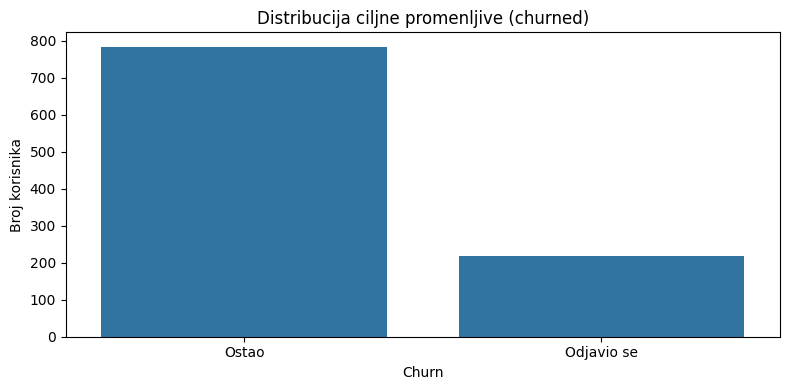

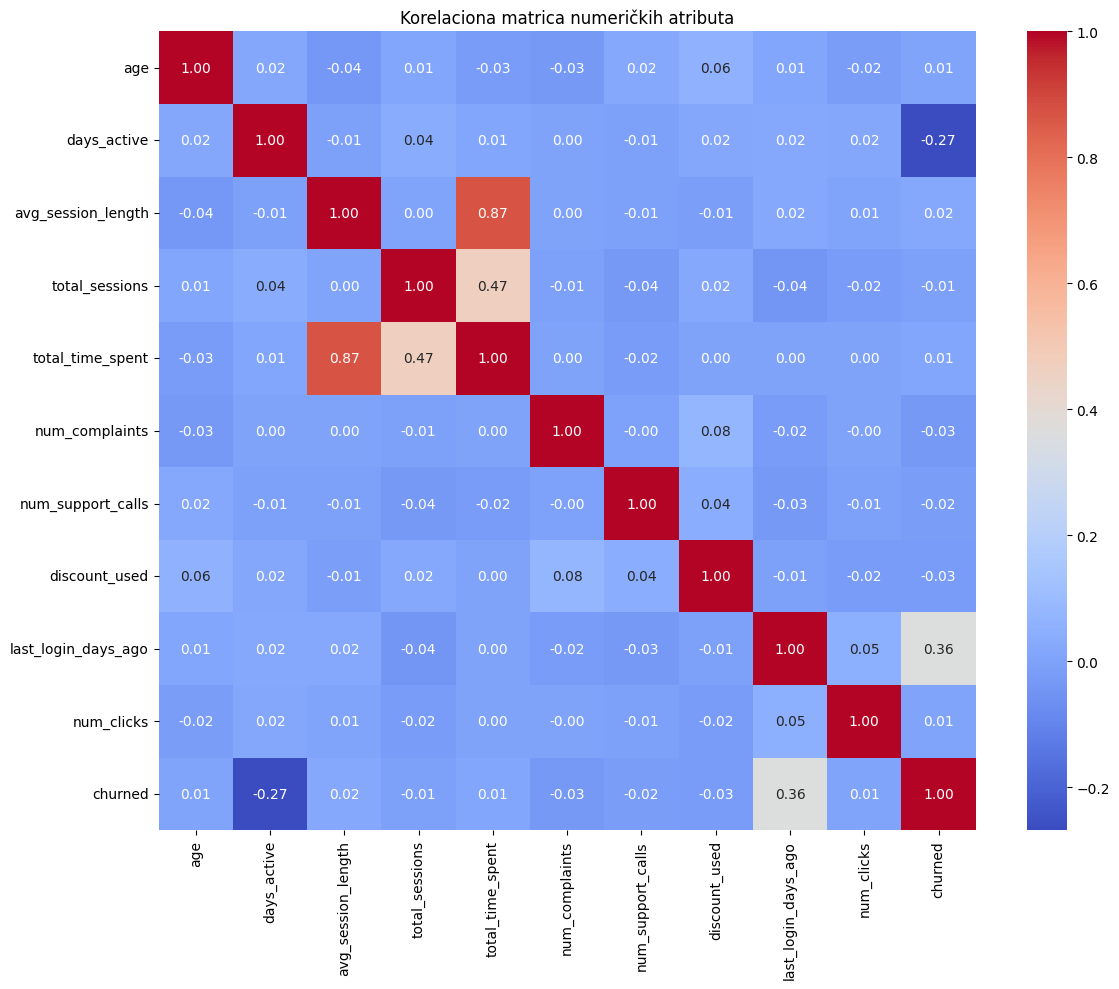

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Kopija bez user_id jer nije informativna
df_eda = df.drop(columns=["user_id"])

# Pregled osnovne statistike numeričkih kolona
basic_stats = df_eda.describe()

# Distribucija ciljne varijable
churn_distribution = df_eda['churned'].value_counts(normalize=True)

# Korelaciona matrica
correlation_matrix = df_eda.select_dtypes(include=[np.number]).corr()

# Vizualizacije
plt.figure(figsize=(8, 4))
sns.countplot(x='churned', data=df_eda)
plt.title('Distribucija ciljne promenljive (churned)')
plt.xticks([0, 1], ['Ostao', 'Odjavio se'])
plt.xlabel('Churn')
plt.ylabel('Broj korisnika')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Korelaciona matrica numeričkih atributa')
plt.tight_layout()
plt.show()




dodati jos neke grafike i slicno!

Priprema podataka:

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# 1. Uklanjanje outliera (negativne vrednosti koje ne bi smele da postoje)
df_clean = df_eda[
    (df_eda['avg_session_length'] > 0) &
    (df_eda['total_time_spent'] > 0)
].reset_index(drop=True)

# 2. Definisanje feature i target
X = df_clean.drop(columns=['churned'])
y = df_clean['churned']

# 3. Kolone za obradu
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# 4. Definisanje transformacija
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# 5. Kombinovani transformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# 6. Deljenje skupa na trening i test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Transformisani X-ovi
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Broj instanci i shape nakon obrade
X_train_processed.shape, X_test_processed.shape



((797, 21), (200, 21))

Modelovanje

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

# Definisanje modela
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "Neural Network (MLP)": MLPClassifier(hidden_layer_sizes=(50, 30), max_iter=300, random_state=42)
}

# Treniranje i evaluacija modela
results = {}

for name, model in models.items():
    model.fit(X_train_processed, y_train)
    y_pred = model.predict(X_test_processed)
    y_prob = model.predict_proba(X_test_processed)[:, 1] if hasattr(model, "predict_proba") else y_pred
    results[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_prob),
        "report": classification_report(y_test, y_pred, output_dict=True)
    }

# Prikaz metrika u tabelarnom obliku
summary_df = pd.DataFrame({
    model: {
        "Accuracy": metrics["accuracy"],
        "ROC AUC": metrics["roc_auc"],
        "Precision (1)": metrics["report"]["1"]["precision"],
        "Recall (1)": metrics["report"]["1"]["recall"],
        "F1-score (1)": metrics["report"]["1"]["f1-score"]
    }
    for model, metrics in results.items()
}).T.round(3)

summary_df # za klasu 1(korisnici koji su se odjavili)


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:33:35] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


,Accuracy,ROC AUC,Precision (1),Recall (1),F1-score (1)
Logistic Regression,0.905,0.961,0.821,0.727,0.771
Random Forest,0.985,1.000,1.000,0.932,0.965
XGBoost,1.000,1.000,1.000,1.000,1.000
Neural Network (MLP),0.940,0.985,0.881,0.841,0.860


SHAP (XAI)

In [15]:
import shap

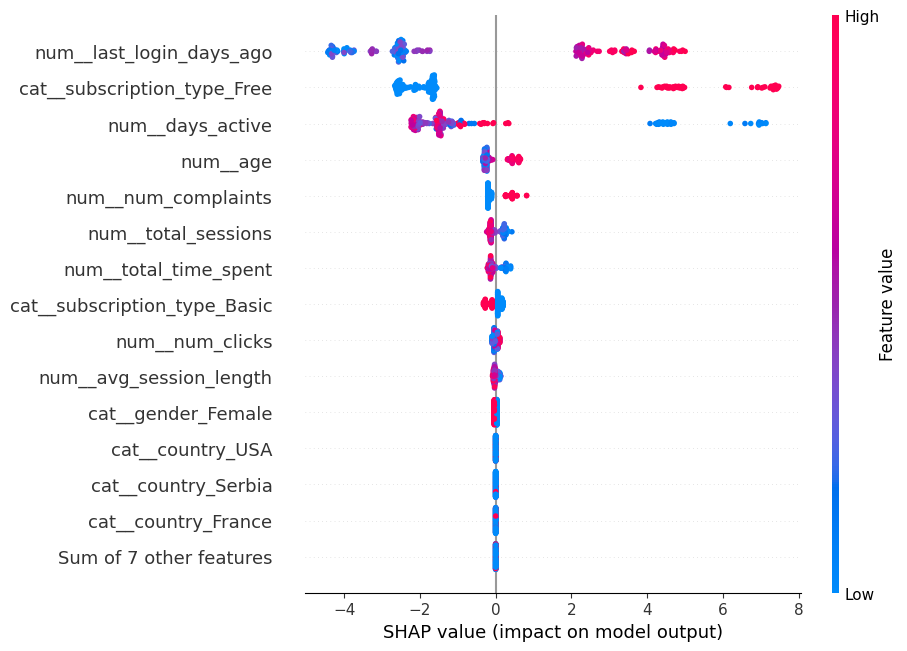

In [16]:
best_model = models["XGBoost"]

# SHAP analiza
explainer = shap.Explainer(best_model, X_train_processed, feature_names=preprocessor.get_feature_names_out())
shap_values = explainer(X_test_processed)

# Prikaz najvažnijih osobina – summary plot
shap.plots.beeswarm(shap_values, max_display=15)


shap analiza pomocu TreeExplainer

<ipython-input-18-845f3ad3b584>:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_tree, X_test_processed, feature_names=preprocessor.get_feature_names_out(), max_display=15)


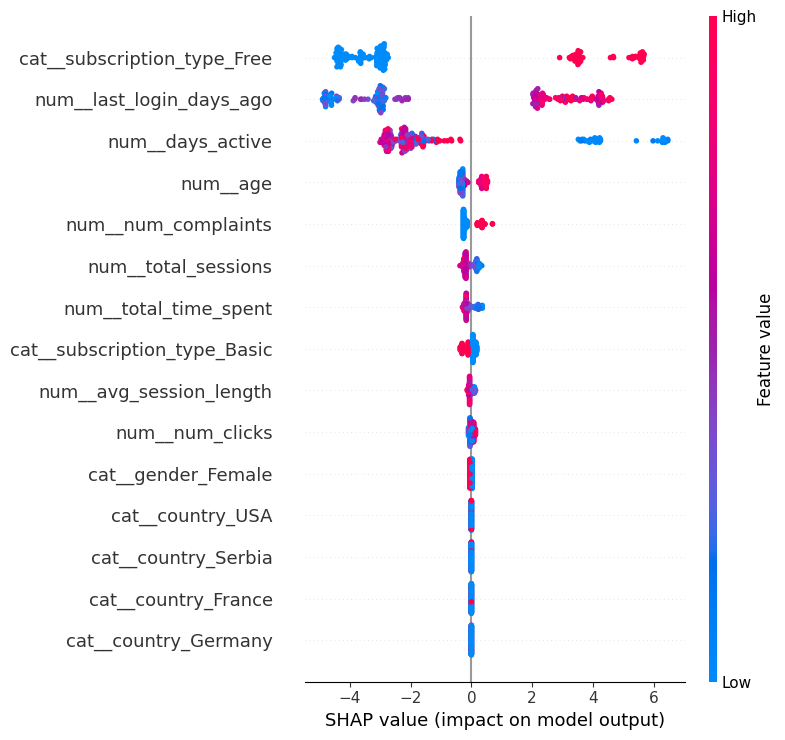

In [18]:

# SHAP analiza pomoću TreeExplainer
explainer_tree = shap.TreeExplainer(best_model)
shap_values_tree = explainer_tree.shap_values(X_test_processed)

# Vizualizacija SHAP vrednosti
shap.summary_plot(shap_values_tree, X_test_processed, feature_names=preprocessor.get_feature_names_out(), max_display=15)

Tumačenje summary plot-a:
Šta vidimo: najvažnije karakteristike koje utiču na odluku modela da korisnik napusti platformu.

Desno (crveno): veće SHAP vrednosti – jači doprinos odluci ka "churn = 1".

Levo (plavo): manji doprinos ili doprinos ka "ne-churn" (ostanak korisnika).

Na primer:

last_login_days_ago i days_active su dominantni faktori odluke.

subscription_type_Free takođe snažno utiče na odluku o odjavljivanju.



Prikaz pojedinacnih sharp vrednosti za jednog korisnika - moze se dodati i za jos nekog

In [30]:
# Prvo prikaz SHAP vrednosti za jednog korisnika (npr. prvi iz test skupa)

index = 0
shap.initjs()
shap.force_plot(
    base_value=explainer_tree.expected_value,
    shap_values=shap_values_tree[index],
    features=X_test_processed[index],
    feature_names=preprocessor.get_feature_names_out()
)


SHAP Dependence Plota:
Prikazuje SHAP vrednosti za last_login_days_ago po instanci,

Otkiva nelinearnosti i interakcije,

Koristan je za dubinsku interpretaciju uticaja konkretne osobine.

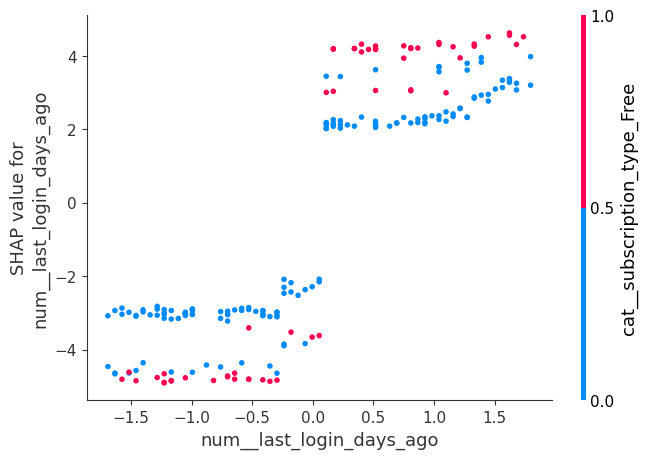

In [33]:
import shap
import matplotlib.pyplot as plt

# SHAP vrednosti
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_processed)

# SHAP dependence plot za najvažniju osobinu (npr. last_login_days_ago)
shap.dependence_plot(
    'num__last_login_days_ago',   # koristi prefiks "num__" jer je to ime kolone nakon transformacije
    shap_values,
    X_test_processed,
    feature_names=preprocessor.get_feature_names_out()
)


Cross-validation xgboost modela sa 5-fold stratifikacijom

In [20]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

# Kombinovani pipeline: preprocessing + model
xgb_pipeline = make_pipeline(preprocessor, XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))

# Cross-validacija (5-fold stratified)
cv_scores = cross_val_score(xgb_pipeline, X, y, cv=5, scoring='f1')

# Prikaz rezultata
cv_scores_mean = np.mean(cv_scores)
cv_scores_std = np.std(cv_scores)

cv_scores_mean, cv_scores_std


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:42:26] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:42:26] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:42:27] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:42:27] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:42:27] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

(np.float64(0.9931016042780749), np.float64(0.00913233718646797))

(np.float64(0.9931016042780749), np.float64(0.00913233718646797))
 ovo znaci da je prosecan f1 score 0.993
 a da je standardna devijacija +- 0.009

 to su izuzetno visoki rezultati i ukazuju da je model izuzetno precizan i konzistentan na razlicitim podskupovima

Kroz shap smo uradili feature importance, ali mozemo i klasicno da uradimo pa da uporedimo

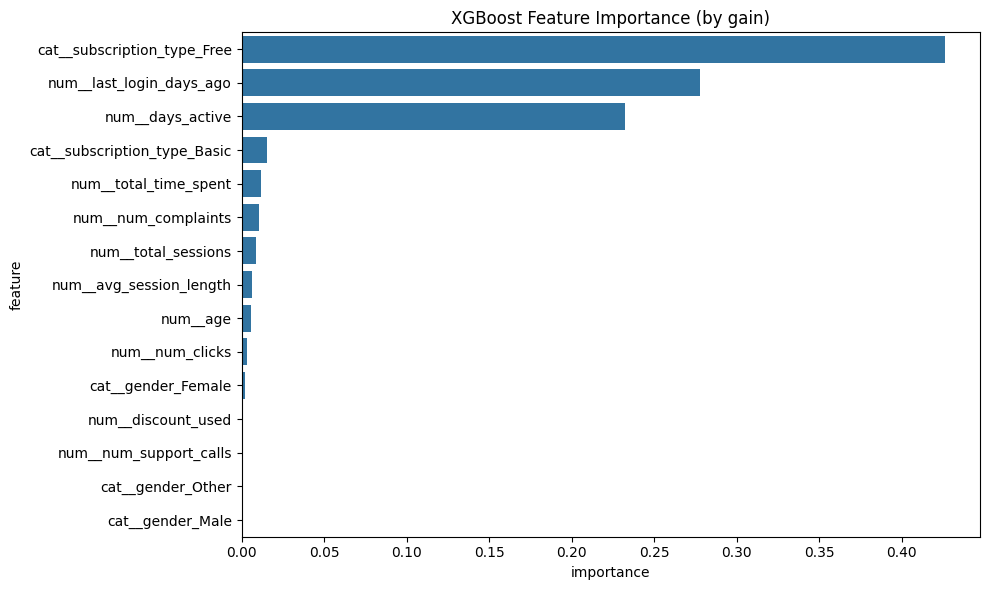

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Dobijanje važnosti osobina iz modela
importances = best_model.feature_importances_
features = preprocessor.get_feature_names_out()

# Sortiranje i vizualizacija
importance_df = pd.DataFrame({'feature': features, 'importance': importances})
importance_df = importance_df.sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importance_df.head(15))
plt.title('XGBoost Feature Importance (by gain)')
plt.tight_layout()
plt.show()
